In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

In [28]:
BATCH_SIZE = 128
IMAGE_SIZE = 28
CHANNELS = 1
LATENT_DIM = 100
NUM_EPOCHS = 50
LR = 0.0002
BETA1 = 0.5       # adam beta parameter

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [29]:
transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Normalize to [-1, 1]
])

dataset = torchvision.datasets.MNIST(root="./data", download=True, transform=transform)
loader = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

print(f"Dataset size: {len(dataset)}")
print(f"Batches per epoch: {len(loader)}")

Dataset size: 60000
Batches per epoch: 469


In [30]:
class Generator(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 256 * 7 * 7)
        self.net = nn.Sequential(
            nn.BatchNorm2d(256),
            # ConvTranspose2d(in_channels, out_channels, kernel_size, stride, padding, bias)
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 1, kernel_size=3, stride=1, padding=1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, 256, 7, 7)
        x = self.net(x)
        return x


In [31]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.AdaptiveAvgPool2d(1)
        )

        self.fc = nn.Sequential(
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.net(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

In [32]:
G = Generator(latent_dim=LATENT_DIM).to(DEVICE)
D = Discriminator().to(DEVICE)

# Initialize weights
def init_weights(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
        nn.init.normal_(m.weight, 0.0, 0.02)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.normal_(m.weight, 1.0, 0.02)
        nn.init.constant_(m.bias, 0)

G.apply(init_weights)
D.apply(init_weights)
print(f"\nGenerator parameters: {sum(p.numel() for p in G.parameters()):,}")
print(f"Discriminator parameters: {sum(p.numel() for p in D.parameters()):,}")


Generator parameters: 1,923,776
Discriminator parameters: 657,409


In [33]:
criterion = nn.BCELoss()
opt_G = optim.Adam(G.parameters(), lr=LR, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=LR, betas=(0.5, 0.999))

g_losses = []  # Track generator losses
d_losses = []  # Track discriminator losses

print("\nStarting training...\n")

for epoch in range(NUM_EPOCHS):
    epoch_g_loss = 0
    epoch_d_loss = 0

    progress_bar = tqdm(loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")

    for batch_idx, (real, _) in enumerate(progress_bar):
        real = real.to(DEVICE)
        batch_size = real.size(0)
        real_labels = torch.ones(batch_size, 1).to(DEVICE)
        fake_labels = torch.zeros(batch_size, 1).to(DEVICE)
        # training discriminator
        z = torch.randn(batch_size, LATENT_DIM).to(DEVICE)
        fake = G(z)
        D_real = D(real)
        D_fake = D(fake.detach())
        loss_real = criterion(D_real, real_labels)
        loss_fake = criterion(D_fake, fake_labels)
        loss_D = (loss_real + loss_fake) / 2
        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # training generator
        z = torch.randn(batch_size, LATENT_DIM).to(DEVICE)
        fake = G(z)
        output = D(fake)
        loss_G = criterion(output, real_labels)  # fool discriminator
        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()
        epoch_g_loss += loss_G.item()
        epoch_d_loss += loss_D.item()
        progress_bar.set_postfix({'D_loss': loss_D.item(), 'G_loss': loss_G.item()})

    avg_g_loss = epoch_g_loss / len(loader)
    avg_d_loss = epoch_d_loss / len(loader)
    g_losses.append(avg_g_loss)
    d_losses.append(avg_d_loss)
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] | Avg Loss D: {avg_d_loss:.4f}, Avg Loss G: {avg_g_loss:.4f}")



Starting training...



Epoch 1/50: 100%|██████████| 469/469 [00:21<00:00, 21.90it/s, D_loss=0.537, G_loss=0.832]


Epoch [1/50] | Avg Loss D: 0.5726, Avg Loss G: 0.8554


Epoch 2/50: 100%|██████████| 469/469 [00:22<00:00, 20.77it/s, D_loss=0.52, G_loss=1.1]


Epoch [2/50] | Avg Loss D: 0.5079, Avg Loss G: 0.9966


...

Epoch [48/50] | Avg Loss D: 0.2587, Avg Loss G: 1.9659


Epoch 49/50: 100%|██████████| 469/469 [00:22<00:00, 21.13it/s, D_loss=0.22, G_loss=1.77]


Epoch [49/50] | Avg Loss D: 0.2568, Avg Loss G: 1.9946


Epoch 50/50: 100%|██████████| 469/469 [00:22<00:00, 20.85it/s, D_loss=0.192, G_loss=2.26]

Epoch [50/50] | Avg Loss D: 0.2557, Avg Loss G: 1.9895


Saved: training_curves.png


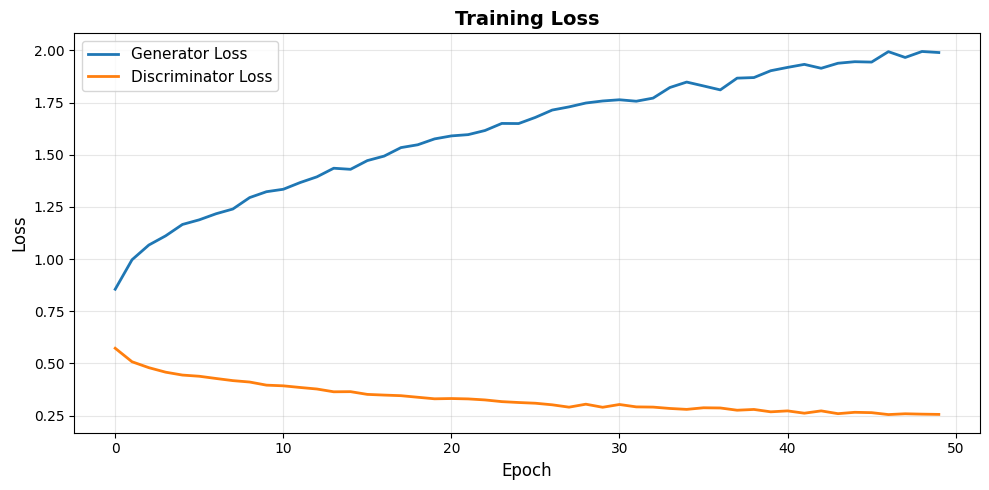

In [35]:
plt.figure(figsize=(10, 5))
plt.plot(g_losses, label='Generator Loss', linewidth=2)
plt.plot(d_losses, label='Discriminator Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training Loss', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
print("Saved: training_curves.png")
plt.show()


Generating final 15 digits for submission...
Saved: final_generated_digits.png


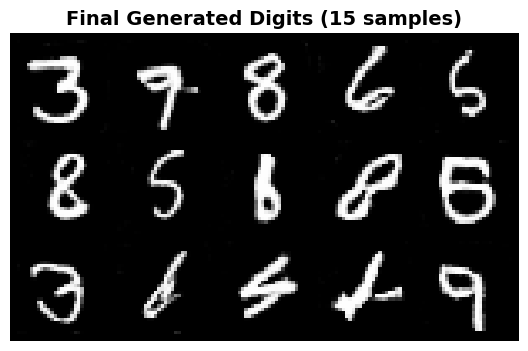

<Figure size 600x600 with 0 Axes>

In [34]:
print("\nGenerating final 15 digits for submission...")
G.eval()
with torch.no_grad():
    z = torch.randn(15, LATENT_DIM).to(DEVICE)
    final_images = G(z)
final_images = (final_images + 1) / 2

def show_images(images, title="Generated Digits", filename=None):
    images = images.cpu()
    grid = torchvision.utils.make_grid(images, nrow=5, normalize=False, value_range=(0, 1))
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.imshow(np.transpose(grid.numpy(), (1, 2, 0)), cmap='gray')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axis('off')
    if filename:
        plt.savefig(filename, dpi=150, bbox_inches='tight')
        print(f"Saved: {filename}")
    plt.figure(figsize=(6, 6))
    plt.tight_layout()
    plt.show()

show_images(final_images, title="Final Generated Digits (15 samples)", filename='final_generated_digits.png')